# set up

In [1]:
import sys
if sys.platform == 'linux':
    sys.path.append("/home/qix/MultiNeuronGLM")
else:
    sys.path.append("D:/Github/MultiNeuronGLM")

In [2]:
import pandas as pd
import utility_functions as utils
import GLM
from DataLoader import Allen_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
sns.set_theme()

# Justifying trial type > instatanous state > instatanous speed

## Set up for 14 conditions and 6 areas 

probeA = AM, probeB = PM, probeC = V1, probeD = LM, probeE = AL, probeF = RL

In [3]:
# Load selected group_id
import pickle
with open('group_id_selected_a_c/membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_selected_a_c/condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

In [4]:
# Use self trained K-means results, which have a better likelihood
import pickle
with open('group_id_all_a_c/membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_all_a_c/condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

In [5]:
probe_list = ['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF']

for iprobe, probe in enumerate(probe_list):
    num_cross_pop = []
    for icondition in range(len(membership)):
        aaa = membership[icondition]
        num_cross_pop.append( len(aaa[np.logical_and( aaa['probe']==probe , aaa['group_id']==0)]) )
    print(f"{probe} has {np.mean(num_cross_pop)} neurons in cross-pop in average. ")

probeA has 12.225 neurons in cross-pop in average. 
probeB has 14.95 neurons in cross-pop in average. 
probeC has 16.9 neurons in cross-pop in average. 
probeD has 10.625 neurons in cross-pop in average. 
probeE has 7.375 neurons in cross-pop in average. 
probeF has 8.225 neurons in cross-pop in average. 


In [6]:
# Load LFP data
start_time = 0.0
end_time = 0.5
padding = 0.5
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


In [7]:
# Just to get a wider range of speed
start_time = -0.5
end_time = 1.0
padding = 0
V1_wider = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
                   stimulus_name='drifting_gratings')

V1_wider.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)


## No speed

After the 0 th iteration of fitting: 67216.38474951134
After the 0 th iteration of warping: 65108.12786331463
After the 1 th iteration of fitting: 64326.943071550326
After the 1 th iteration of warping: 64005.20447455458
After the 2 th iteration of fitting: 64033.417946682726
After the 2 th iteration of warping: 63844.53615703377
After the 3 th iteration of fitting: 64003.33991444758
After the 3 th iteration of warping: 63829.45137191315
After the 4 th iteration of fitting: 64013.22224685868
After the 4 th iteration of warping: 63807.686265822216
After the 5 th iteration of fitting: 64004.97745336749
After the 5 th iteration of warping: 63803.07489928005
After the 6 th iteration of fitting: 64006.37880993947
After the 6 th iteration of warping: 63805.180352003765
After the 7 th iteration of fitting: 64013.5809913982
After the 7 th iteration of warping: 63811.14635048162
After the 8 th iteration of fitting: 64018.20844159625
After the 8 th iteration of warping: 63816.50181710825
After t

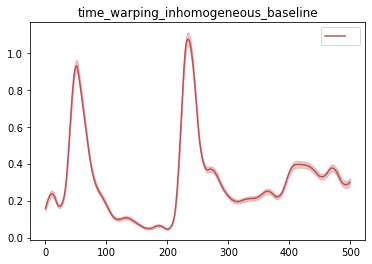

In [138]:
best_time_diff = 0
smooth_std = 20
num_basis_baseline = 30
num_varying_linear = 30
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
penalty = 1e-5

select_trials = np.full(V1.ntrial, True)
# select_trials = V1.running_trial_index

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
# model.add_effect('coupling', 'probeC', **coupling_filter_params)
# model.add_effect('trial_coef')
model.fit_time_warping_baseline('probeC', verbose=True, max_iter=10, penalty=penalty)
GLM.plot_GLM_compare(model)

## Simple linear term of speed

After the 0 th iteration of fitting: 67013.9208288987
After the 0 th iteration of warping: 64913.200645412384
After the 1 th iteration of fitting: 64135.82086545582
After the 1 th iteration of warping: 63827.53419039815
After the 2 th iteration of fitting: 63873.85038973164
After the 2 th iteration of warping: 63687.56022371583
After the 3 th iteration of fitting: 63828.53267534733
After the 3 th iteration of warping: 63664.42111941316
After the 4 th iteration of fitting: 63833.96548960345
After the 4 th iteration of warping: 63665.20338046585
After the 5 th iteration of fitting: 63830.335067441876
After the 5 th iteration of warping: 63664.997970246404
After the 6 th iteration of fitting: 63847.756659652296
After the 6 th iteration of warping: 63673.79289606852
After the 7 th iteration of fitting: 63867.83102423842
After the 7 th iteration of warping: 63664.70156301909
After the 8 th iteration of fitting: 63848.857591011176
After the 8 th iteration of warping: 63675.695593993
After th

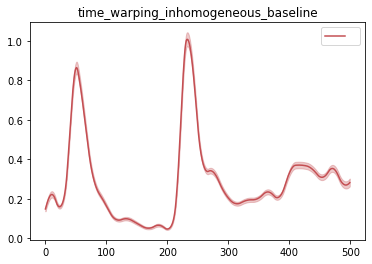

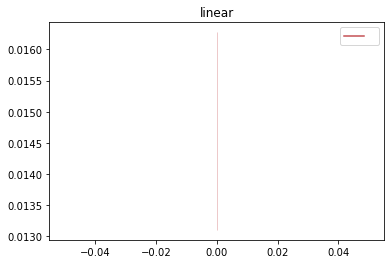

In [139]:
best_time_diff = 0
smooth_std = 20
num_basis_baseline = 30
num_varying_linear = 30
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
penalty = 1e-5

select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
smo = utils.kernel_smoothing(V1_wider.speed, 
                             smooth_std)[(500+best_time_diff):(1000+best_time_diff),select_trials]
model.add_effect('linear', smo, num=num_varying_linear)
# model.add_effect('coupling', 'probeC', **coupling_filter_params)
# model.add_effect('trial_coef')
model.fit_time_warping_baseline('probeC', verbose=True, max_iter=10, penalty=penalty)
GLM.plot_GLM_compare(model)

## Simple binary term of state

After the 0 th iteration of fitting: 67069.93459982004
After the 0 th iteration of warping: 64955.079797204955
After the 1 th iteration of fitting: 64158.39321037087
After the 1 th iteration of warping: 63858.289591645065
After the 2 th iteration of fitting: 63896.97221053284
After the 2 th iteration of warping: 63713.630723018774
After the 3 th iteration of fitting: 63866.58380480412
After the 3 th iteration of warping: 63696.775364324094
After the 4 th iteration of fitting: 63858.65734444609
After the 4 th iteration of warping: 63701.702946118334
After the 5 th iteration of fitting: 63874.86701491349
After the 5 th iteration of warping: 63682.14466276108
After the 6 th iteration of fitting: 63863.787117256186
After the 6 th iteration of warping: 63700.0150944825
After the 7 th iteration of fitting: 63878.33368686352
After the 7 th iteration of warping: 63710.901772115205
After the 8 th iteration of fitting: 63893.33275380215
After the 8 th iteration of warping: 63700.05561034187
Afte

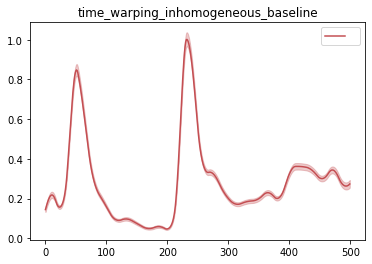

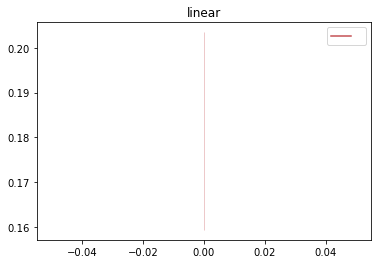

In [140]:
best_time_diff = 0
smooth_std = 20
num_basis_baseline = 30
num_varying_linear = 30
threshold = 1
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
penalty = 1e-5

select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
smo = utils.kernel_smoothing(V1_wider.speed, 
                             smooth_std)[(500+best_time_diff):(1000+best_time_diff),select_trials]
instantaneous_state = np.zeros_like(smo)
instantaneous_state[smo>threshold] = 1
model.add_effect('linear', instantaneous_state, num=num_varying_linear)
# model.add_effect('coupling', 'probeC', **coupling_filter_params)
# model.add_effect('trial_coef')
model.fit_time_warping_baseline('probeC', verbose=True, max_iter=10, penalty=penalty)
GLM.plot_GLM_compare(model)

## Time-varying linear term of speed

After the 0 th iteration of fitting: 66296.67135496755
After the 0 th iteration of warping: 64125.315755752825
After the 1 th iteration of fitting: 63467.68190281837
After the 1 th iteration of warping: 63262.598064696314
After the 2 th iteration of fitting: 63275.58843773896
After the 2 th iteration of warping: 63164.67699957568
After the 3 th iteration of fitting: 63248.0514337749
After the 3 th iteration of warping: 63123.454367462946
After the 4 th iteration of fitting: 63233.24605678344
After the 4 th iteration of warping: 63119.877700014644
After the 5 th iteration of fitting: 63230.00878248354
After the 5 th iteration of warping: 63107.36880001376
After the 6 th iteration of fitting: 63221.703179525786
After the 6 th iteration of warping: 63093.84353428953
After the 7 th iteration of fitting: 63209.64986020108
After the 7 th iteration of warping: 63087.41366807871
After the 8 th iteration of fitting: 63203.832931009885
After the 8 th iteration of warping: 63078.633027464
After t

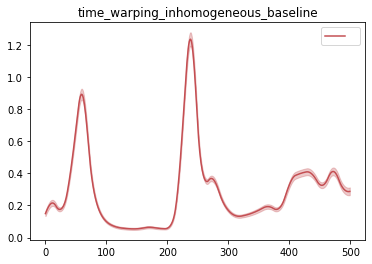

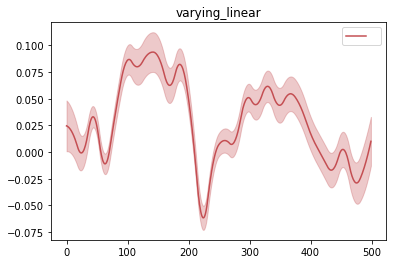

In [141]:
best_time_diff = 100
smooth_std = 20
num_basis_baseline = 30
num_varying_linear = 30
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
penalty = 1e-5

select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
smo = utils.kernel_smoothing(V1_wider.speed, 
                             smooth_std)[(500+best_time_diff):(1000+best_time_diff),select_trials]
model.add_effect('varying_linear', smo, num=num_varying_linear)
# model.add_effect('coupling', 'probeC', **coupling_filter_params)
# model.add_effect('trial_coef')
model.fit_time_warping_baseline('probeC', verbose=True, max_iter=10, penalty=penalty)
GLM.plot_GLM_compare(model)

## Time-varying binary term of state

After the 0 th iteration of fitting: 66173.74037371157
After the 0 th iteration of warping: 64152.86311088536
After the 1 th iteration of fitting: 63572.672141643125
After the 1 th iteration of warping: 63396.2026486428
After the 2 th iteration of fitting: 63389.30914074339
After the 2 th iteration of warping: 63300.08997004521
After the 3 th iteration of fitting: 63336.40315593518
After the 3 th iteration of warping: 63249.3532077737
After the 4 th iteration of fitting: 63287.64335280133
After the 4 th iteration of warping: 63200.63480398346
After the 5 th iteration of fitting: 63256.1871145889
After the 5 th iteration of warping: 63172.128169394135
After the 6 th iteration of fitting: 63236.00204934766
After the 6 th iteration of warping: 63149.02232307699
After the 7 th iteration of fitting: 63209.21569696195
After the 7 th iteration of warping: 63120.014994881814
After the 8 th iteration of fitting: 63182.01670749673
After the 8 th iteration of warping: 63094.15451162685
After the 

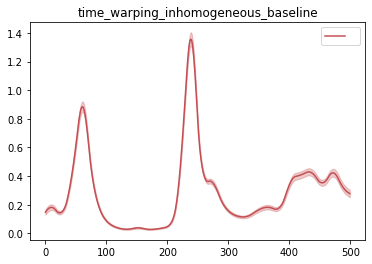

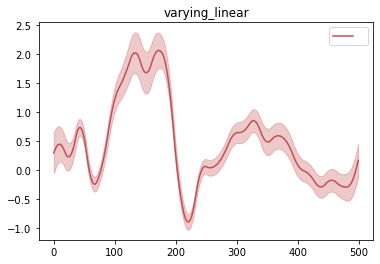

In [142]:
best_time_diff = 100
smooth_std = 20
num_basis_baseline = 30
num_varying_linear = 30
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
penalty = 1e-5

select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
smo = utils.kernel_smoothing(V1_wider.speed, 
                             smooth_std)[(500+best_time_diff):(1000+best_time_diff),select_trials]
instantaneous_state = np.zeros_like(smo)
instantaneous_state[smo>threshold] = 1
model.add_effect('varying_linear', instantaneous_state, num=num_varying_linear)
# model.add_effect('coupling', 'probeC', **coupling_filter_params)
# model.add_effect('trial_coef')
model.fit_time_warping_baseline('probeC', verbose=True, max_iter=10, penalty=penalty)
GLM.plot_GLM_compare(model)

## Trial-wise binary term of state

After the 0 th iteration of fitting: 65917.73559321549
After the 0 th iteration of warping: 63749.25507012677
After the 1 th iteration of fitting: 63059.05007985738
After the 1 th iteration of warping: 62894.92573622089
After the 2 th iteration of fitting: 62875.06074940583
After the 2 th iteration of warping: 62788.754655534256
After the 3 th iteration of fitting: 62825.27614704841
After the 3 th iteration of warping: 62755.490190633835
After the 4 th iteration of fitting: 62808.3354615844
After the 4 th iteration of warping: 62738.17456809137
After the 5 th iteration of fitting: 62799.860353851895
After the 5 th iteration of warping: 62741.79606768995
After the 6 th iteration of fitting: 62803.20840508999
After the 6 th iteration of warping: 62733.725933191854
After the 7 th iteration of fitting: 62795.9898937335
After the 7 th iteration of warping: 62726.89939492676
After the 8 th iteration of fitting: 62789.365860079946
After the 8 th iteration of warping: 62715.86306561656
After t

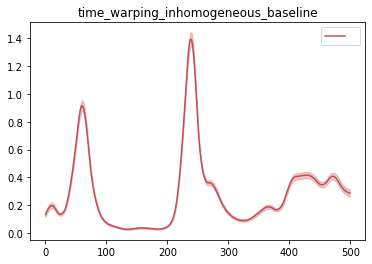

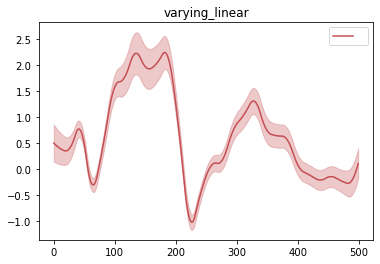

In [143]:
best_time_diff = 100
smooth_std = 20
num_basis_baseline = 30
num_varying_linear = 30
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
penalty = 1e-5

select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)

trial_state = np.zeros_like(V1.speed)
for i in range(trial_state.shape[1]):
    if V1.running_trial_index[i]:
        trial_state[:,i] = 1.0

model.add_effect('varying_linear', trial_state, num=num_varying_linear)
# model.add_effect('coupling', 'probeC', **coupling_filter_params)
# model.fit('probeC', verbose=True)
# model.add_effect('trial_coef')
model.fit_time_warping_baseline('probeC', verbose=True, max_iter=10, penalty=penalty)
GLM.plot_GLM_compare(model)

## Two-way couping

After the 0 th iteration of fitting: 67003.12130296158
After the 0 th iteration of warping: 64891.71799359196
After the 1 th iteration of fitting: 64100.2382579655
After the 1 th iteration of warping: 63811.32054587389
After the 2 th iteration of fitting: 63848.278905625455
After the 2 th iteration of warping: 63664.18997391547
After the 3 th iteration of fitting: 63816.162176379
After the 3 th iteration of warping: 63639.520594316346
After the 4 th iteration of fitting: 63804.03896724763
After the 4 th iteration of warping: 63604.891586796526
After the 5 th iteration of fitting: 63783.25744647692
After the 5 th iteration of warping: 63585.57087096377
After the 6 th iteration of fitting: 63767.16067610507
After the 6 th iteration of warping: 63562.75352805833
After the 7 th iteration of fitting: 63762.777768156906
After the 7 th iteration of warping: 63554.12219190366
After the 8 th iteration of fitting: 63774.702961362804
After the 8 th iteration of warping: 63535.46156484591
After th

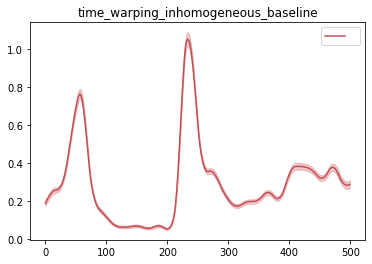

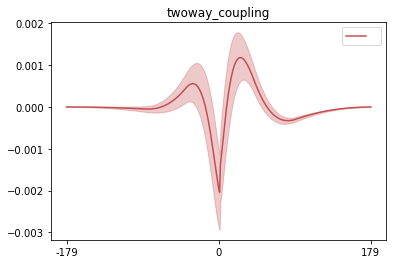

In [144]:
best_time_diff = 100
smooth_std = 20
num_basis_baseline = 30
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
penalty = 1e-5

select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
smo = utils.kernel_smoothing(V1_wider.speed, 
                             smooth_std)[(500+best_time_diff):(1000+best_time_diff),select_trials]
model.add_effect('twoway_coupling', smo, peaks_max=40, num=3, nonlinear=0.4)
# model.add_effect('coupling', 'probeC', **coupling_filter_params)
# model.add_effect('trial_coef')
model.fit_time_warping_baseline('probeC', verbose=True, max_iter=10, penalty=penalty)
GLM.plot_GLM_compare(model)

# Justify coupling effects should contain history effects with 1st/2nd order interaction terms

## Baseline (no coupling)

In [145]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
target_probe = 'probeC'
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 1e2

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
# for j, input_probe in enumerate(probe_list):
#     model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params)
# model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
# for j, input_probe in enumerate(probe_list):
#     model_running.add_effect('coupling', probe_list[j], **coupling_filter_params)
# model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

print(model_running.aic + model_stationary.aic)

63315.00008708797


## Only cross-area coupling

In [ ]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
target_probe = 'probeC'
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 1e2

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
for j, input_probe in enumerate(probe_list):
    if j == 2:
        continue
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params)
# model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
for j, input_probe in enumerate(probe_list):
    if j == 2:
        continue
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params)
# model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

print(model_running.aic + model_stationary.aic)

## Both cross-area coupling and history

This is unstable when doing simulation

In [123]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
target_probe = 'probeC'
tau = 10
coupling_filter_params = {'peaks_max':30, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 1e2

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params)
# model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
for j, input_probe in enumerate(probe_list):
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params)
# model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

print(model_running.aic + model_stationary.aic)

62122.29243777049


## With interaction in history effect

In [119]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
target_probe = 'probeC'
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 1e2

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params)
model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
for j, input_probe in enumerate(probe_list):
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params)
model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

print(model_running.aic + model_stationary.aic)

KeyboardInterrupt: 

## With only 2nd interaction in history effect

In [ ]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
target_probe = 'probeC'
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 1e2

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
for j, input_probe in enumerate(probe_list):
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params)
# model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

print(model_running.aic + model_stationary.aic)

## Interaction in all coupling effects

Not so good

In [ ]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
target_probe = 'probeC'
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 1e2

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params)
    model_stationary.add_effect('interaction', probe_list[j], **coupling_filter_params)
# model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
for j, input_probe in enumerate(probe_list):
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params)
    model_running.add_effect('interaction', probe_list[j], **coupling_filter_params)
# model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

print(model_running.aic + model_stationary.aic)

## Second Interaction in history effect

In [ ]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
target_probe = 'probeC'
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 1e2

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params)
model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
for j, input_probe in enumerate(probe_list):
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params)
model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

print(model_running.aic + model_stationary.aic)

# Adding trial-wise coef

Adding trial-wise coef indeed improve the fit, but also makes the CI of inhomogeneous baseline so big. (should be related to inverse hessian issue) 

In [ ]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
target_probe = 'probeC'
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 1e2

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
model_stationary.add_effect('trial_coef')
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params)
model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
model_running.add_effect('trial_coef')
for j, input_probe in enumerate(probe_list):
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params)
model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

print(model_running.aic + model_stationary.aic)

In [ ]:
model_running.results.bse[0:10]

# Regularization

In [126]:
##### Cell for CV
n_cv = 10
para_list = np.logspace(1, 3, 7)
all_considered_trial_idx = np.where(V1.stationary_trial_index)[0]

max_iter = 10
self_effect = False
target_probe = 'probeC'
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 1e0

##### 
nlogli_rcd = np.zeros((len(para_list), n_cv))
template_for_kf = np.zeros((len(all_considered_trial_idx),1))

from sklearn.model_selection import KFold
kf = KFold(n_splits=n_cv)
kf.get_n_splits(template_for_kf)

for i, penalty in enumerate(tqdm(para_list)):
    j = 0
    for train_index, test_index in kf.split(template_for_kf):
        select_trials = np.full(V1.ntrial, False)
        select_trials[all_considered_trial_idx[train_index]] = True
        test_trials = np.full(V1.ntrial, False)
        test_trials[all_considered_trial_idx[test_index]] = True

        model = GLM.PP_GLM(dataset=V1, 
                           select_trials=select_trials, 
                           membership=membership, 
                           condition_ids=condition_ids)
        model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
#         model.add_effect('trial_coef')
        for j, input_probe in enumerate(probe_list):
            model.add_effect('coupling', probe_list[j], **coupling_filter_params)
        model.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
#         model.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
        model.fit(target_probe, verbose=False, penalty=penalty)

        nlogli_rcd[i, j] = model.test(test_trials)
        j += 1

100%|██████████████████████████████████████| 7/7 [03:12<00:00, 27.50s/it]


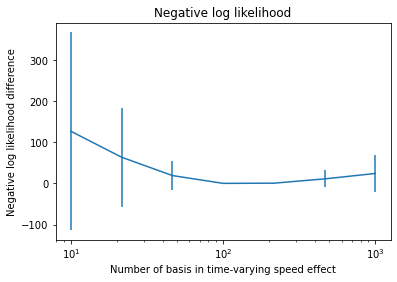

In [127]:
best_id = np.argmin(nlogli_rcd.mean(axis=1))
x = para_list
y = (nlogli_rcd-nlogli_rcd[best_id,:]).mean(axis=1)
dy = 2*(nlogli_rcd-nlogli_rcd[best_id,:]).std(axis=1)/np.sqrt(nlogli_rcd.shape[1])

plt.figure()
plt.errorbar(x, y, yerr=dy)
plt.title(f"Negative log likelihood")
plt.xlabel(f"Number of basis in time-varying speed effect")
plt.ylabel(f"Negative log likelihood difference")
plt.xscale('log')

56498.41749361336


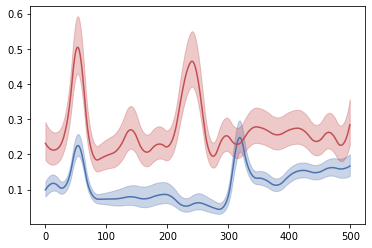

In [96]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
target_probe = 'probeC'
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 1e2

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
model_stationary.add_effect('trial_coef')
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params)
model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
model_running.add_effect('trial_coef')
for j, input_probe in enumerate(probe_list):
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params)
model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

print(model_running.aic + model_stationary.aic)

y, ci = model_stationary.get_filter(ci=True)[0]
x = np.arange(y.shape[0])
plt.plot(x, np.exp(y),label='stationary', color='b')
plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='b', alpha=.3)

y, ci = model_running.get_filter(ci=True)[0]
x = np.arange(y.shape[0])
plt.plot(x, np.exp(y),label='running', color='r')
plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='r', alpha=.3)

# Fit six areas with 14 conditions

## Set up

In [40]:
# Load selected group_id
import pickle
with open('group_id_all_a_c/membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_all_a_c/condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

In [41]:
# Load LFP data
start_time = 0.0
end_time = 0.50
padding = 0.3
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
# V1.get_trial_metric_per_unit_per_trial(metric_type='spike_times')
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


## Decide couping filter hyperparameters

After many tries, the best hyperparameters for coupling filter is 
peaks_max=50, num=6, nonlinear=0.3

In [72]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
target_probe = 'probeC'
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
# model_stationary.add_effect('trial_coef')
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params)
model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
# model_running.add_effect('trial_coef')
for j, input_probe in enumerate(probe_list):
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params)
model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter)

print(model_running.aic + model_stationary.aic)

56397.35536324058


## Fit

In [76]:
num_basis_baseline = 30
max_iter = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
# use_all = [True, True, False, False, False, True]
use_all = [False, False, False, False, False, False]

probe_list = V1.selected_probes
running_filter = {}
stationary_filter = {}
ROI = {}
statistics = {}
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], **coupling_filter_params)
    model.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
    model.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
#     model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=1e-3)
    running_model_list.append(model)
    filter_list = model.get_filter(ci=True)
    running_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        running_filter[i,j] = filter_list[k]
        k += 1
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], **coupling_filter_params)
    model.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
    model.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
#     model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=1e-3)
    stationary_model_list.append(model)
    filter_list = model.get_filter(ci=True)
    stationary_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        stationary_filter[i,j] = filter_list[k]
        k += 1
    
    filter_index = i,-1
    function1 = np.exp( running_filter[filter_index][0] )
    function2 = np.exp( stationary_filter[filter_index][0] )
    ROI[filter_index] = GLM.get_ROI(function1, function2)
    statistics[filter_index] = GLM.get_excursion_test(function1, function2, ROI[filter_index])
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        filter_index = i,j
        function1 = running_filter[filter_index][0]
        function2 = stationary_filter[filter_index][0]
        ROI[filter_index] = GLM.get_ROI(function1, function2)
        statistics[filter_index] = GLM.get_excursion_test(function1, function2, ROI[filter_index])

6it [02:53, 28.95s/it]


In [77]:
statistics

{(0, -1): 4.721222945982243,
 (0, 1): 2.581989441144316,
 (0, 2): 0.27995124450820885,
 (0, 3): 0.11987660171957586,
 (0, 4): 0.29723195520463935,
 (0, 5): 0.1916076051772462,
 (1, -1): 2.0333011856695067,
 (1, 0): 0.2797799614126669,
 (1, 2): 1.7002199707076882,
 (1, 3): 0.121609740437573,
 (1, 4): 0.29022218839354014,
 (1, 5): 0.22105488370743803,
 (2, -1): 4.803934209828957,
 (2, 0): 0.1536286100664726,
 (2, 1): 0.20991483263223343,
 (2, 3): 1.861278490884069,
 (2, 4): 0.26725847953304177,
 (2, 5): 0.1755757888250819,
 (3, -1): 1.8497617131233088,
 (3, 0): 0.4257878877320548,
 (3, 1): 0.6850066472811308,
 (3, 2): 0.18929651712765347,
 (3, 4): 4.099778724745717,
 (3, 5): 0.2727205513543073,
 (4, -1): 4.486733023010749,
 (4, 0): 0.22024240501283246,
 (4, 1): 0.22471149137553245,
 (4, 2): 0.2011395086194174,
 (4, 3): 0.5276887216459881,
 (4, 5): 4.279585926987321,
 (5, -1): 1.8117613620317423,
 (5, 0): 0.21978486522823681,
 (5, 1): 0.7614186027966031,
 (5, 2): 0.20538741546949438,
 (5,

## Excursion test (now I use "without trial-wise coef")

In [311]:
from GLM import get_statistics_null_mp
statistics_null = get_statistics_null_mp(500, V1, membership, condition_ids, probe_list, 
                                         num_basis_baseline, coupling_filter_params)

Starting multiprocessing on linux. 
Cores=5. 
Batch size=50


100%|████████████████████████████████| 500/500 [3:05:39<00:00, 22.28s/it]


## Results with excursion test

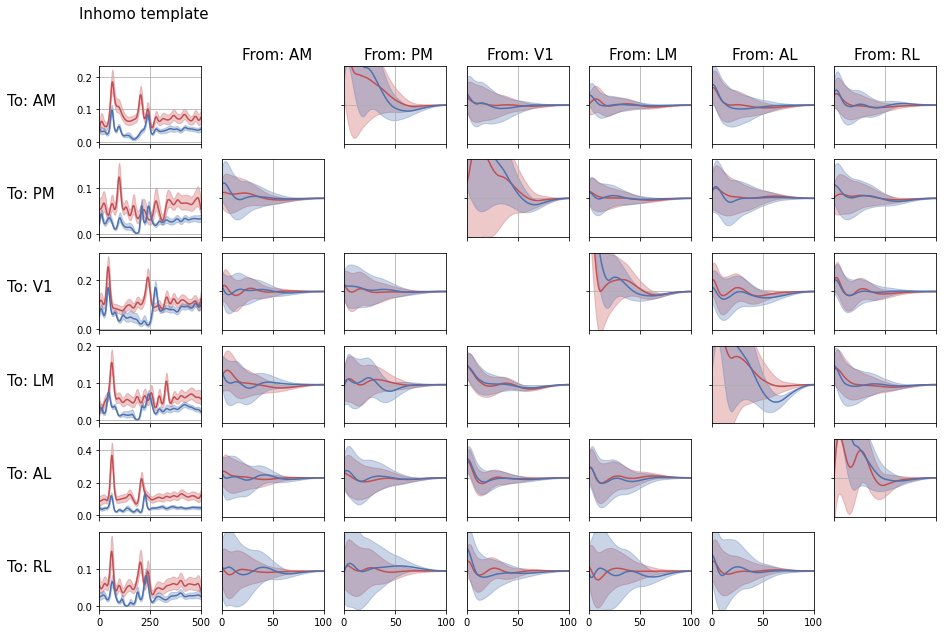

In [78]:
# use_all are all False
name_list = ['AM', 'PM', 'V1', 'LM', 'AL', 'RL']
fontsize = 15

sns.reset_orig()
# sns.set_theme()
plt.subplots(figsize=(15,10))
for i in range(len(probe_list)):
    for j in range(-1, len(probe_list)):
        if i==j:
            continue
        ax = plt.subplot(6, 7, i*7+j+1+1, frameon=True)
        filter_index = i,j
        y, ci = running_filter[filter_index]
        x = np.arange(y.shape[0])
        if j == -1:
            plt.plot(x, np.exp(y),label='running', color='r')
            plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='r', alpha=.3)
        else:
            plt.plot(x, y,label='running', color='r')
            plt.fill_between(x, y-2*ci, y+2*ci, color='r', alpha=.3)
            
        y, ci = stationary_filter[filter_index]
        x = np.arange(y.shape[0])
        if j == -1:
            plt.plot(x, np.exp(y),label='stationary', color='b')
            plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='b', alpha=.3)
            plt.xticks([0, 250, 500])
            plt.xlim([0, 500])
            
        else:
            plt.plot(x, y,label='stationary', color='b')
            plt.fill_between(x, y-2*ci, y+2*ci, color='b', alpha=.3)
            plt.yticks([0])
            plt.ylim([-0.17, 0.17])
            plt.yticks(color='w')
            plt.xticks([0, 50, 100])
            plt.xlim([0, 100])
            if i==0:
                plt.text(20, 0.2, f'From: {name_list[j]}', fontsize=fontsize)
                
        if j==0:
            plt.text(-210, 0, f'To: {name_list[i]}', fontsize=fontsize)
        if i != 5:
            plt.xticks(color='w')
        plt.grid()
        
#         ins = ax.inset_axes([0.6,0.6,0.4,0.4])
#         sns.kdeplot(statistics_null[filter_index], linewidth=2, ax=ins, fill=True)
#         ins.axvline(statistics[filter_index], linewidth=1.5, color='r')
#         ins.set_xticks([])
#         ins.set_yticks([])
#         ins.set_ylabel('')
        
        if i==0 and j==2:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(-450, 0, f'To: AM', fontsize=fontsize)
        if i==1 and j==0:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(20, 0.61, f'From: AM', fontsize=fontsize)
        if i==0 and j==-1:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(-100, 0.38, f'Inhomo template', fontsize=fontsize)

#         if pvalue[filter_index]<=0.01 and j!=-1:
#             ax.patch.set_alpha(0.3)
#             ax.set_facecolor('yellow')


In [374]:
pvalue = {}
for i in range(len(probe_list)):
    for j in range(-1, len(probe_list)):
        if i==j:
            continue
        filter_index = i,j
        pvalue[filter_index] = 1-np.sum( statistics[filter_index]>statistics_null[filter_index])/len(statistics_null[filter_index])

In [375]:
pvalue

{(0, -1): 0.0,
 (0, 1): 0.04800000000000004,
 (0, 2): 0.604,
 (0, 3): 0.278,
 (0, 4): 0.17000000000000004,
 (0, 5): 0.0020000000000000018,
 (1, -1): 0.0,
 (1, 0): 0.23199999999999998,
 (1, 2): 0.804,
 (1, 3): 0.766,
 (1, 4): 0.506,
 (1, 5): 0.09599999999999997,
 (2, -1): 0.0,
 (2, 0): 0.43799999999999994,
 (2, 1): 0.006000000000000005,
 (2, 3): 0.0,
 (2, 4): 0.20399999999999996,
 (2, 5): 0.0,
 (3, -1): 0.0,
 (3, 0): 0.898,
 (3, 1): 0.038000000000000034,
 (3, 2): 0.006000000000000005,
 (3, 4): 0.138,
 (3, 5): 0.344,
 (4, -1): 0.0,
 (4, 0): 0.19799999999999995,
 (4, 1): 0.05800000000000005,
 (4, 2): 0.87,
 (4, 3): 0.014000000000000012,
 (4, 5): 0.016000000000000014,
 (5, -1): 0.0,
 (5, 0): 0.34199999999999997,
 (5, 1): 0.29200000000000004,
 (5, 2): 0.18200000000000005,
 (5, 3): 0.22599999999999998,
 (5, 4): 0.378}

### With trial-wise coef

/tmp/ipykernel_630/1254868213.py:16: RuntimeWarning: overflow encountered in exp
  plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='r', alpha=.3)
/tmp/ipykernel_630/1254868213.py:25: RuntimeWarning: overflow encountered in exp
  plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='b', alpha=.3)
/tmp/ipykernel_630/1254868213.py:16: RuntimeWarning: overflow encountered in exp
  plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='r', alpha=.3)
/tmp/ipykernel_630/1254868213.py:25: RuntimeWarning: overflow encountered in exp
  plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='b', alpha=.3)
/tmp/ipykernel_630/1254868213.py:16: RuntimeWarning: overflow encountered in exp
  plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='r', alpha=.3)
/tmp/ipykernel_630/1254868213.py:25: RuntimeWarning: overflow encountered in exp
  plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='b', alpha=.3)
/tmp/ipykernel_630/1254868213.py:16: Run

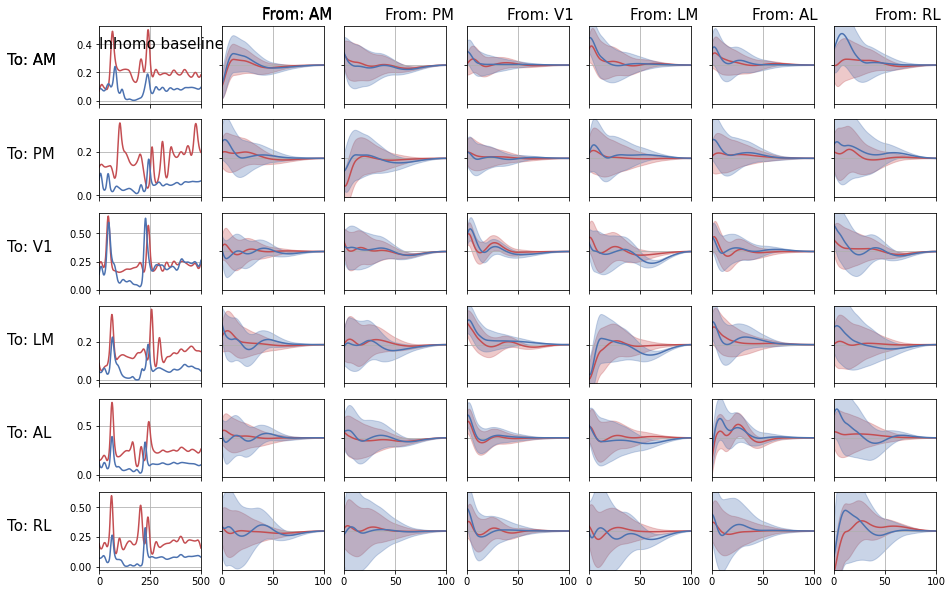

In [287]:
# use_all are all False
name_list = ['AM', 'PM', 'V1', 'LM', 'AL', 'RL']
fontsize = 15

sns.reset_orig()
# sns.set_theme()
plt.subplots(figsize=(15,10))
for i in range(len(probe_list)):
    for j in range(-1, len(probe_list)):
        ax = plt.subplot(6, 7, i*7+j+1+1, frameon=True)
        filter_index = i,j
        y, ci = running_filter[filter_index]
        x = np.arange(y.shape[0])
        if j == -1:
            plt.plot(x, np.exp(y),label='running', color='r')
            plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='r', alpha=.3)
        else:
            plt.plot(x, y,label='running', color='r')
            plt.fill_between(x, y-2*ci, y+2*ci, color='r', alpha=.3)
            
        y, ci = stationary_filter[filter_index]
        x = np.arange(y.shape[0])
        if j == -1:
            plt.plot(x, np.exp(y),label='stationary', color='b')
            plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='b', alpha=.3)
            plt.xticks([0, 250, 500])
            plt.xlim([0, 500])
            
        else:
            plt.plot(x, y,label='stationary', color='b')
            plt.fill_between(x, y-2*ci, y+2*ci, color='b', alpha=.3)
            plt.yticks([0])
            plt.ylim([-0.17, 0.17])
            plt.yticks(color='w')
            plt.xticks([0, 50, 100])
            plt.xlim([0, 100])
            if i==0:
                plt.text(40, 0.2, f'From: {name_list[j]}', fontsize=fontsize)
                
        if j==0:
            plt.text(-210, 0, f'To: {name_list[i]}', fontsize=fontsize)
        if i != 5:
            plt.xticks(color='w')
        plt.grid()
        
#         ins = ax.inset_axes([0.6,0.6,0.4,0.4])
#         sns.kdeplot(statistics_null[filter_index], linewidth=2, ax=ins, fill=True)
#         ins.axvline(statistics[filter_index], linewidth=1.5, color='r')
#         ins.set_xticks([])
#         ins.set_yticks([])
#         ins.set_ylabel('')
        
        if i==0 and j==2:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(-450, 0, f'To: AM', fontsize=fontsize)
        if i==1 and j==0:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(40, 0.61, f'From: AM', fontsize=fontsize)
        if i==0 and j==-1:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(0, 0.37, f'Inhomo baseline', fontsize=fontsize)



### Without trial-wise coef

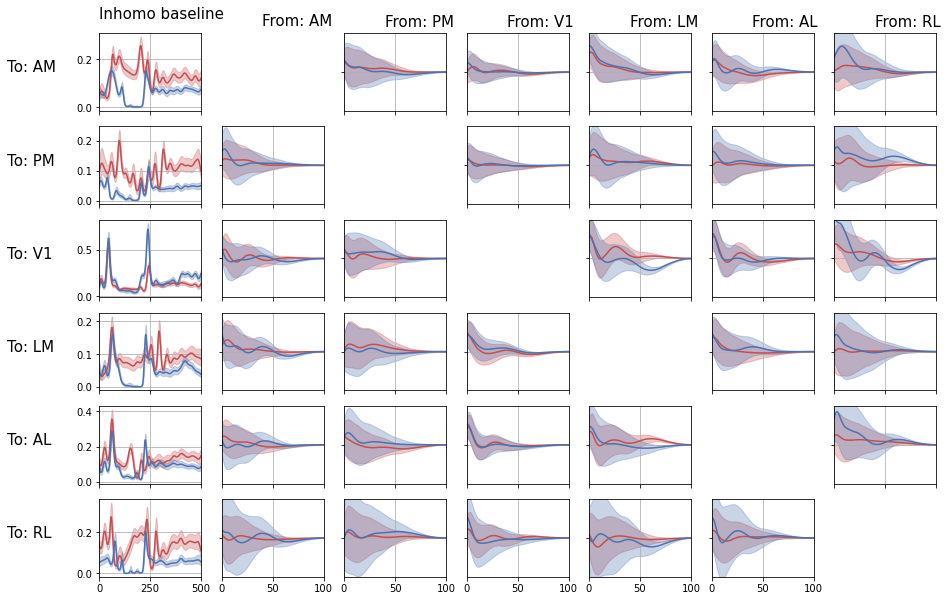

In [293]:
# use_all are all False
name_list = ['AM', 'PM', 'V1', 'LM', 'AL', 'RL']
fontsize = 15

sns.reset_orig()
# sns.set_theme()
plt.subplots(figsize=(15,10))
for i in range(len(probe_list)):
    for j in range(-1, len(probe_list)):
        if i==j:
            continue
        ax = plt.subplot(6, 7, i*7+j+1+1, frameon=True)
        filter_index = i,j
        y, ci = running_filter[filter_index]
        x = np.arange(y.shape[0])
        if j == -1:
            plt.plot(x, np.exp(y),label='running', color='r')
            plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='r', alpha=.3)
        else:
            plt.plot(x, y,label='running', color='r')
            plt.fill_between(x, y-2*ci, y+2*ci, color='r', alpha=.3)
            
        y, ci = stationary_filter[filter_index]
        x = np.arange(y.shape[0])
        if j == -1:
            plt.plot(x, np.exp(y),label='stationary', color='b')
            plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='b', alpha=.3)
            plt.xticks([0, 250, 500])
            plt.xlim([0, 500])
            
        else:
            plt.plot(x, y,label='stationary', color='b')
            plt.fill_between(x, y-2*ci, y+2*ci, color='b', alpha=.3)
            plt.yticks([0])
            plt.ylim([-0.17, 0.17])
            plt.yticks(color='w')
            plt.xticks([0, 50, 100])
            plt.xlim([0, 100])
            if i==0:
                plt.text(40, 0.2, f'From: {name_list[j]}', fontsize=fontsize)
                
        if j==0:
            plt.text(-210, 0, f'To: {name_list[i]}', fontsize=fontsize)
        if i != 5:
            plt.xticks(color='w')
        plt.grid()
        
#         ins = ax.inset_axes([0.6,0.6,0.4,0.4])
#         sns.kdeplot(statistics_null[filter_index], linewidth=2, ax=ins, fill=True)
#         ins.axvline(statistics[filter_index], linewidth=1.5, color='r')
#         ins.set_xticks([])
#         ins.set_yticks([])
#         ins.set_ylabel('')
        
        if i==0 and j==2:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(-450, 0, f'To: AM', fontsize=fontsize)
        if i==1 and j==0:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(40, 0.61, f'From: AM', fontsize=fontsize)
        if i==0 and j==-1:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(0, 0.37, f'Inhomo baseline', fontsize=fontsize)



# Mean firing rate

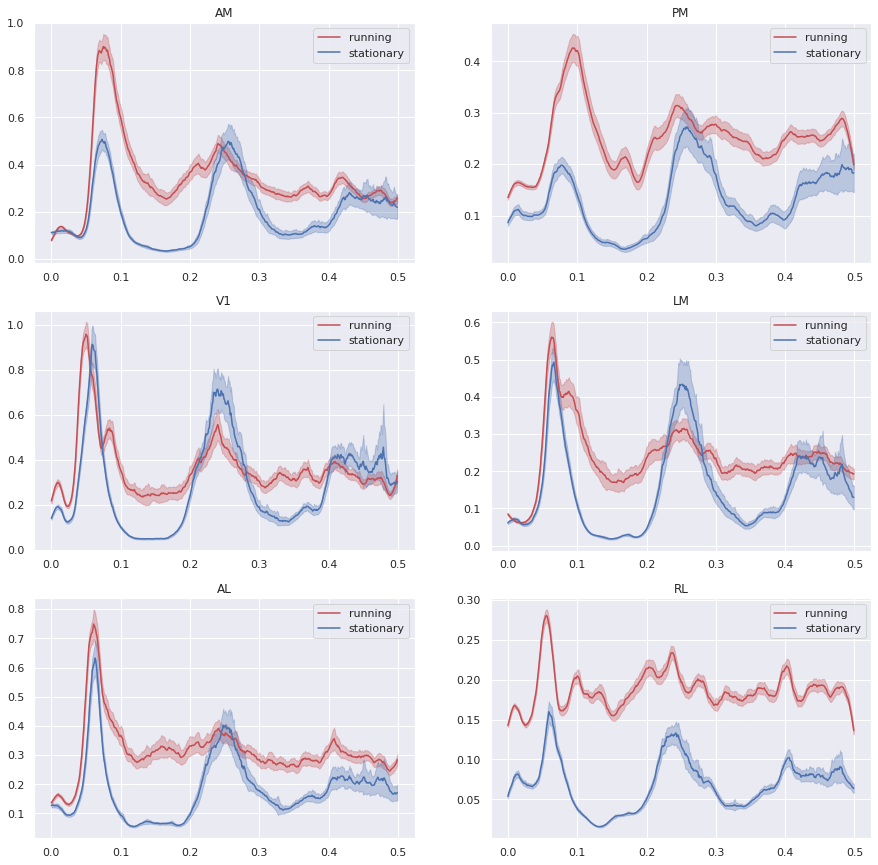

In [8]:
sns.set_theme()
num_basis_baseline = 30
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}

probe_list = V1.selected_probes
running_filter = {}
stationary_filter = {}
ROI = {}
statistics = {}
plt.subplots(figsize=(15,15))

for i, target_probe in enumerate(probe_list):
    plt.subplot(3, 2, i+1)
    
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        model.add_effect('coupling', probe_list[j], **coupling_filter_params)
    model.fit(probe_list[i], verbose=False)
    plot_target = np.exp(model.log_lmbd)
    x = model.dataset.time_line
    y = plot_target.mean(axis=1)
    ci = plot_target.std(axis=1)/np.sqrt(plot_target.shape[1])
    color = 'r'
    label = 'running'
    plt.plot(x, y.squeeze(),label=label, color=color)
    plt.fill_between(x, (y-2*ci), (y+2*ci), color=color, alpha=.3)
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        model.add_effect('coupling', probe_list[j], **coupling_filter_params)
    model.fit(probe_list[i], verbose=False)
    plot_target = np.exp(model.log_lmbd)
    x = model.dataset.time_line
    y = plot_target.mean(axis=1)
    ci = plot_target.std(axis=1)/np.sqrt(plot_target.shape[1])
    color = 'b'
    label = 'stationary'
    plt.plot(x, y.squeeze(),label=label, color=color)
    plt.fill_between(x, (y-2*ci), (y+2*ci), color=color, alpha=.3)
    plt.legend()
    plt.title(utils.PROBE_CORRESPONDING[probe_list[i]])

# Contributions of each effect

In [443]:
num_basis_baseline = 30
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
max_iter = 10

probe_list = V1.selected_probes
running_filter = {}
stationary_filter = {}
ROI = {}
statistics = {}

for i, target_probe in enumerate(probe_list):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        model.add_effect('coupling', probe_list[j], use_all=use_all[j], **coupling_filter_params)
    model.fit_time_warping_baseline(probe_list[i], verbose=False, max_iter=max_iter)
    filter_list = model.get_filter_output(ci=True)
    running_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        running_filter[i,j] = filter_list[k]
        k += 1
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        model.add_effect('coupling', probe_list[j], use_all=use_all[j], **coupling_filter_params)
    model.fit_time_warping_baseline(probe_list[i], verbose=False, max_iter=max_iter)
    filter_list = model.get_filter_output(ci=True)
    stationary_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        stationary_filter[i,j] = filter_list[k]
        k += 1
    
    filter_index = i,-1
    function1 = np.exp( running_filter[filter_index][0] )
    function2 = np.exp( stationary_filter[filter_index][0] )
    ROI[filter_index] = GLM.get_ROI(function1, function2)
    statistics[filter_index] = GLM.get_excursion_test(function1, function2, ROI[filter_index])
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        filter_index = i,j
        function1 = running_filter[filter_index][0]
        function2 = stationary_filter[filter_index][0]
        ROI[filter_index] = GLM.get_ROI(function1, function2)
        statistics[filter_index] = GLM.get_excursion_test(function1, function2, ROI[filter_index])

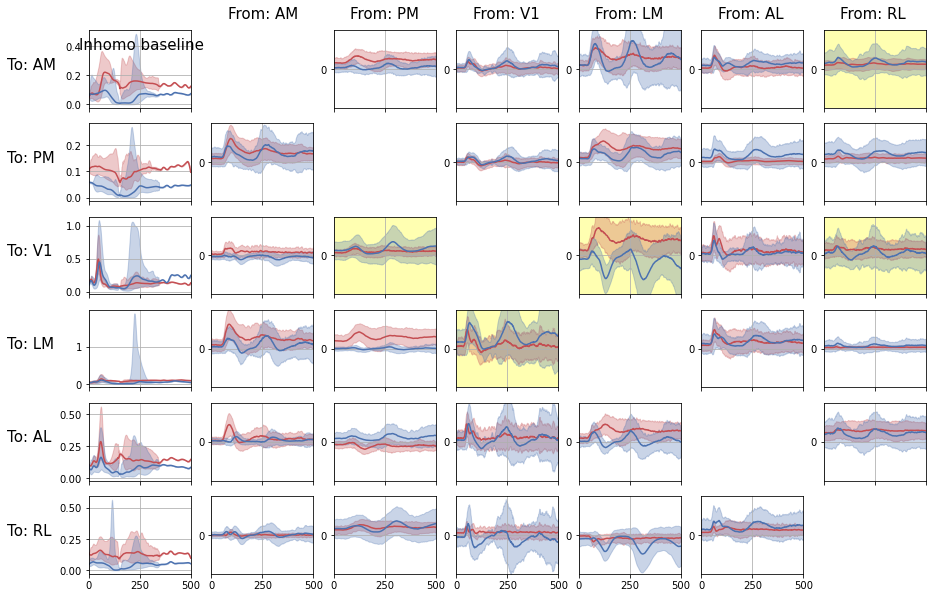

In [444]:
name_list = ['AM', 'PM', 'V1', 'LM', 'AL', 'RL']
fontsize=15

sns.reset_orig()
# sns.set_theme()
plt.subplots(figsize=(15,10))
for i in range(len(probe_list)):
    for j in range(-1, len(probe_list)):
        if i==j:
            continue
        ax = plt.subplot(6, 7, i*7+j+1+1, frameon=True)
        filter_index = i,j
        y, ci = running_filter[filter_index]
        x = np.arange(y.shape[0])
        if j == -1:
            plt.plot(x, np.exp(y),label='running', color='r')
            plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='r', alpha=.3)
        else:
            plt.plot(x, y,label='running', color='r')
            plt.fill_between(x, y-2*ci, y+2*ci, color='r', alpha=.3)
            
        y, ci = stationary_filter[filter_index]
        x = np.arange(y.shape[0])
        if j == -1:
            plt.plot(x, np.exp(y),label='stationary', color='b')
            plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='b', alpha=.3)
            plt.xticks([0, 250, 500])
            plt.xlim([0, 500])
            
        else:
            plt.plot(x, y,label='stationary', color='b')
            plt.fill_between(x, y-2*ci, y+2*ci, color='b', alpha=.3)
            plt.yticks([0])
            plt.ylim([-1, 1])
#             plt.yticks(color='w')
            plt.xticks([0, 250, 500])
            plt.xlim([0, 500])
            if i==0:
                plt.text(80, 1.3, f'From: {name_list[j]}', fontsize=fontsize)
                
        if j==0:
            plt.text(-1000, 0, f'To: {name_list[i]}', fontsize=fontsize)
        if i != 5:
            plt.xticks(color='w')
        plt.grid()
        
        
        if i==0 and j==2:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(-2200, 0, f'To: AM', fontsize=fontsize)
        if i==1 and j==0:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(80, 3.7, f'From: AM', fontsize=fontsize)
        if i==0 and j==-1:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(-50, 0.38, f'Inhomo baseline', fontsize=fontsize)
            
        if pvalue[filter_index]<=0.01 and j!=-1:
            ax.patch.set_alpha(0.3)
            ax.set_facecolor('yellow')


# Plot graphs

Possible inference to do:

inference on filters: 

(abondon for now because most filters are the same under running and stationary conditions)\
H0: a coupling filter is all zeros\
Do simulation under null. Test statistics can be excursion, or just sum(abs(filter))\
In this way we get p-value that tells how significant this filter is\

inference on an effect's output: \
first average across trials then calculate KS/KL/Wasserstein from a uniform distribution\
calculate {(KS of all effects sum)-(KS of all without the i-th effect's output)} \
bootstrap 1000 times

## log p-value of excursion test graph

Doesn't seem very useful. But it's a good way to add simulation and parametric bootstrap under null. 

## KS test statistics (amount of information) graph

In [402]:
name_dict = {-1:"stimu", 0:"AM", 1:"PM", 2:"V1", 3:"LM", 4:"AL", 5:"RL"}
angle_list = [90, 65, 0, -90, -135, 165, 115]
dis_from_center = [1, 1, 0.5 ,1 ,1, 0.8, 1]

import networkx as nx
G = nx.DiGraph()
G.add_nodes_from([ name for name in name_dict.values() ])
pos_standard = {}
for i, angle in enumerate(angle_list):
    dis = dis_from_center[i]
    pos_standard[name_dict[i-1]] = dis*np.array([np.cos(angle/360*2*np.pi), 
                                                 np.sin(angle/360*2*np.pi)])

### all peaks

In [9]:
num_basis_baseline = 30
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
time_range = [0.0, 0.35]
auto_pick = 1

probe_list = V1.selected_probes
running12 = {}
stationary12 = {}
ROI = {}
statistics = {}

for i, target_probe in enumerate(probe_list):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], **coupling_filter_params)
    model.fit(probe_list[i], verbose=False)
    filter_list = model.get_filter_contribution(time_range=time_range, auto_pick=auto_pick)
    running12[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
        running12[i,j] = filter_list[k]
        k += 1
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], **coupling_filter_params)
    model.fit(probe_list[i], verbose=False)
    filter_list = model.get_filter_contribution(time_range=time_range, auto_pick=auto_pick)
    stationary12[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
        stationary12[i,j] = filter_list[k]
        k += 1
    


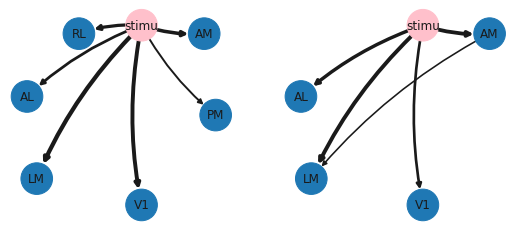

In [10]:
measure_type = 1    # KL:0, KS:1, Wasser:2
plot_thres = 0.1
plot_amp = 15

import networkx as nx

plt.subplots(figsize=(9,4))
plt.subplot(1,2,1)
to_plot_result = stationary12
G = nx.DiGraph()
name_dict = {-1:"stimu", 0:"AM", 1:"PM", 2:"V1", 3:"LM", 4:"AL", 5:"RL"}
for pair, value in to_plot_result.items():
    if value[measure_type] >= plot_thres and pair[0]!=pair[1]:
        G.add_edge(name_dict[pair[1]], name_dict[pair[0]], weight=(value[measure_type]*plot_amp))

edges = G.edges()
weights = [G[u][v]['weight'] for u,v in edges]
edge_labels = nx.get_edge_attributes(G, "weight")
for key, value in edge_labels.items():
    edge_labels[key] = round(edge_labels[key]/plot_amp,3)

color_list = ['#1f78b4' for node in G]
color_list[0] = 'pink'
nx.draw(G, pos_standard, with_labels=True, node_size=1000, width=weights, 
        connectionstyle='arc3, rad = 0.1', node_color=color_list)
# nx.draw_networkx_edge_labels(G, pos, edge_labels)


plt.subplot(1,2,2)
to_plot_result = running12
G = nx.DiGraph()
name_dict = {-1:"stimu", 0:"AM", 1:"PM", 2:"V1", 3:"LM", 4:"AL", 5:"RL"}
for pair, value in to_plot_result.items():
    if value[measure_type] >= plot_thres and pair[0]!=pair[1]:
        G.add_edge(name_dict[pair[1]], name_dict[pair[0]], weight=(value[measure_type]*plot_amp))

edges = G.edges()
weights = [G[u][v]['weight'] for u,v in edges]
edge_labels = nx.get_edge_attributes(G, "weight")
for key, value in edge_labels.items():
    edge_labels[key] = round(edge_labels[key]/plot_amp,3)

color_list = ['#1f78b4' for node in G]
color_list[0] = 'pink'
nx.draw(G, pos_standard, with_labels=True, node_size=1000, width=weights, 
        connectionstyle='arc3, rad = 0.1', node_color=color_list)
# nx.draw_networkx_edge_labels(G, pos, edge_labels)

### peak 1

In [403]:
num_basis_baseline = 30
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
time_range = [0.0, 0.15]
auto_pick = 1
max_iter = 10

probe_list = V1.selected_probes
running1 = {}
stationary1 = {}
ROI = {}
statistics = {}

for i, target_probe in enumerate(probe_list):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        model.add_effect('coupling', probe_list[j], **coupling_filter_params)
    model.fit_time_warping_baseline(probe_list[i], verbose=False, max_iter=max_iter)
    filter_list = model.get_filter_contribution(time_range=time_range, auto_pick=auto_pick)
    running1[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        running1[i,j] = filter_list[k]
        k += 1
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        model.add_effect('coupling', probe_list[j], **coupling_filter_params)
    model.fit_time_warping_baseline(probe_list[i], verbose=False, max_iter=max_iter)
    filter_list = model.get_filter_contribution(time_range=time_range, auto_pick=auto_pick)
    stationary1[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        stationary1[i,j] = filter_list[k]
        k += 1


In [439]:
def get_discrete_weight(weight, step1=0.2, step2=0.12, step3=0.08):
    if weight >=step1:
        return 4
    if weight >=step2:
        return 2.5
    elif weight >=step3:
        return 1.5
    else:
        return 0

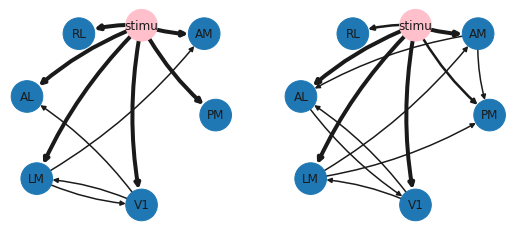

In [441]:
measure_type = 1    # KL:0, KS:1, Wasser:2
plot_thres = 0.07
plot_amp = 15

import networkx as nx

plt.subplots(figsize=(9,4))
plt.subplot(1,2,1)
to_plot_result = stationary1
G = nx.DiGraph()
name_dict = {-1:"stimu", 0:"AM", 1:"PM", 2:"V1", 3:"LM", 4:"AL", 5:"RL"}
for pair, value in to_plot_result.items():
    if value[measure_type] >= plot_thres and pair[0]!=pair[1]:
        weight = get_discrete_weight((value[measure_type]), step3=plot_thres)
        G.add_edge(name_dict[pair[1]], name_dict[pair[0]], weight=weight)

edges = G.edges()
weights = [G[u][v]['weight'] for u,v in edges]
edge_labels = nx.get_edge_attributes(G, "weight")
for key, value in edge_labels.items():
    edge_labels[key] = round(edge_labels[key]/plot_amp,3)

color_list = ['#1f78b4' for node in G]
color_list[0] = 'pink'
nx.draw(G, pos_standard, with_labels=True, node_size=1000, width=weights, 
        connectionstyle='arc3, rad = 0.1', node_color=color_list)
# nx.draw_networkx_edge_labels(G, pos, edge_labels)


plt.subplot(1,2,2)
to_plot_result = running1
G = nx.DiGraph()
name_dict = {-1:"stimu", 0:"AM", 1:"PM", 2:"V1", 3:"LM", 4:"AL", 5:"RL"}
for pair, value in to_plot_result.items():
    if value[measure_type] >= plot_thres and pair[0]!=pair[1]:
        weight = get_discrete_weight((value[measure_type]), step3=plot_thres)
        G.add_edge(name_dict[pair[1]], name_dict[pair[0]], weight=weight)

edges = G.edges()
weights = [G[u][v]['weight'] for u,v in edges]
edge_labels = nx.get_edge_attributes(G, "weight")
for key, value in edge_labels.items():
    edge_labels[key] = round(edge_labels[key]/plot_amp,3)

color_list = ['#1f78b4' for node in G]
color_list[0] = 'pink'
nx.draw(G, pos_standard, with_labels=True, node_size=1000, width=weights, 
        connectionstyle='arc3, rad = 0.1', node_color=color_list)
# nx.draw_networkx_edge_labels(G, pos, edge_labels)

In [405]:
stationary1[2, -1][measure_type], running1[2, -1][measure_type]

(0.336382152037251, 0.2568837034361151)

### peak 2

In [406]:
num_basis_baseline = 30
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
time_range = [0.15, 0.35]
auto_pick = 1
max_iter = 10

probe_list = V1.selected_probes
running2 = {}
stationary2 = {}
ROI = {}
statistics = {}

for i, target_probe in enumerate(probe_list):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        model.add_effect('coupling', probe_list[j], **coupling_filter_params)
    model.fit_time_warping_baseline(probe_list[i], verbose=False, max_iter=max_iter)
    filter_list = model.get_filter_contribution(time_range=time_range, auto_pick=auto_pick)
    running2[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        running2[i,j] = filter_list[k]
        k += 1
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        model.add_effect('coupling', probe_list[j], **coupling_filter_params)
    model.fit_time_warping_baseline(probe_list[i], verbose=False, max_iter=max_iter)
    filter_list = model.get_filter_contribution(time_range=time_range, auto_pick=auto_pick)
    stationary2[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        stationary2[i,j] = filter_list[k]
        k += 1


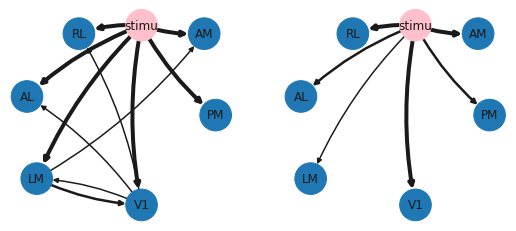

In [442]:
measure_type = 1    # KL:0, KS:1, Wasser:2
plot_thres = 0.07
plot_amp = 15

import networkx as nx

plt.subplots(figsize=(9,4))
plt.subplot(1,2,1)
to_plot_result = stationary2
G = nx.DiGraph()
name_dict = {-1:"stimu", 0:"AM", 1:"PM", 2:"V1", 3:"LM", 4:"AL", 5:"RL"}
for pair, value in to_plot_result.items():
    if value[measure_type] >= plot_thres and pair[0]!=pair[1]:
        weight = get_discrete_weight((value[measure_type]), step3=plot_thres)
        G.add_edge(name_dict[pair[1]], name_dict[pair[0]], weight=weight)

edges = G.edges()
weights = [G[u][v]['weight'] for u,v in edges]
edge_labels = nx.get_edge_attributes(G, "weight")
for key, value in edge_labels.items():
    edge_labels[key] = round(edge_labels[key]/plot_amp,3)

color_list = ['#1f78b4' for node in G]
color_list[0] = 'pink'
nx.draw(G, pos_standard, with_labels=True, node_size=1000, width=weights, 
        connectionstyle='arc3, rad = 0.1', node_color=color_list)
# nx.draw_networkx_edge_labels(G, pos, edge_labels)


plt.subplot(1,2,2)
to_plot_result = running2
G = nx.DiGraph()
name_dict = {-1:"stimu", 0:"AM", 1:"PM", 2:"V1", 3:"LM", 4:"AL", 5:"RL"}
for pair, value in to_plot_result.items():
    if value[measure_type] >= plot_thres and pair[0]!=pair[1]:
        weight = get_discrete_weight((value[measure_type]), step3=plot_thres)
        G.add_edge(name_dict[pair[1]], name_dict[pair[0]], weight=weight)

edges = G.edges()
weights = [G[u][v]['weight'] for u,v in edges]
edge_labels = nx.get_edge_attributes(G, "weight")
for key, value in edge_labels.items():
    edge_labels[key] = round(edge_labels[key]/plot_amp,3)

color_list = ['#1f78b4' for node in G]
color_list[0] = 'pink'
nx.draw(G, pos_standard, with_labels=True, node_size=1000, width=weights, 
        connectionstyle='arc3, rad = 0.1', node_color=color_list)
# nx.draw_networkx_edge_labels(G, pos, edge_labels)

# Simulation

Should copy code from "Simulation and check ..." file

The following code is out of date

In [42]:
max_iter = 10
num_basis_baseline = 30
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
# use_all = [True, True, False, False, False, True]
use_all = [False, False, False, False, False, False]
tau_list = [30, 30, 20, 25, 22, 10]

probe_list = V1.selected_probes
running_filter = {}
stationary_filter = {}
running_model_list = []
stationary_model_list = []

for i, target_probe in enumerate(probe_list):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        model.add_effect('coupling', probe_list[j], use_all=use_all[j], **coupling_filter_params)
#     model.add_effect('trial_coef')
#     model.add_effect('refractory', probe_list[i], tau=tau_list[i])
    model.fit_time_warping_baseline(probe_list[i], verbose=False, max_iter=max_iter)
    running_model_list.append(model)
    filter_list = model.get_filter(ci=True)
    running_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        running_filter[i,j] = filter_list[k]
        k += 1
    
#     select_trials = V1.stationary_trial_index
#     model = GLM.PP_GLM(dataset=V1, 
#                        select_trials=select_trials, 
#                        membership=membership, 
#                        condition_ids=condition_ids)
#     model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
#     for j, input_probe in enumerate(probe_list):
#         model.add_effect('coupling', probe_list[j], use_all=use_all[j], **coupling_filter_params)
# #     model.add_effect('trial_coef')
# #     model.add_effect('refractory', probe_list[i], tau=tau_list[i])
#     model.fit(probe_list[i], verbose=False)
#     stationary_model_list.append(model)
#     filter_list = model.get_filter(ci=True)
#     stationary_filter[i,-1] = filter_list[0]
#     k = 1
#     for j, input_probe in enumerate(probe_list):
#         stationary_filter[i,j] = filter_list[k]
#         k += 1

In [59]:
model_list = running_model_list

import copy
import numpy.random
nneuron = len(model_list)
# Get three dimension matrix of coupling filters for better computing. 
max_histories = 1
nt = model_list[0].nt
# allowed_effect_type = ['inhomogeneous_baseline', 'coupling']
allowed_effect_type = ['inhomogeneous_baseline', 'coupling', 'trial_coef']
coupling_mat = np.zeros((max_histories, nneuron, nneuron))
baseline_mat = np.zeros((nt, nneuron))
spikes = np.zeros((nt, nneuron, 1))
probe2num = {}
for iprobe, probe in enumerate(probe_list):
    probe2num[probe] = iprobe

for ineuron in range(nneuron):
    assert all(effect_type in allowed_effect_type for effect_type in model_list[ineuron].effect_type_list), "Only support inhomogeneous_baseline and coupling effects now!"
    model = model_list[ineuron]
    for ieffect, effect_type in enumerate(model.effect_type_list):
        
        if effect_type in ['inhomogeneous_baseline', ]:
            baseline_mat[:, ineuron] = model.filters[ieffect]
        elif effect_type in ['coupling']:
            nhistories = len(model.filters[ieffect])
            probe_name = utils.PROBE_CORRESPONDING_INVERSE[model.basis_name[ieffect][-2:]]
            iprobe = probe2num[probe_name]
            if nhistories > max_histories:
                coupling_mat_old = coupling_mat
                coupling_mat = np.zeros((nhistories, nneuron, nneuron))
                coupling_mat[-max_histories:, :, :] = coupling_mat_old
                max_histories = nhistories
            coupling_mat[-nhistories:, iprobe, ineuron] = np.flip(model.filters[ieffect])

log_firing_rate = baseline_mat[:,:,np.newaxis]
spikes[0,:,0] = np.random.poisson(np.exp(log_firing_rate[0,:,0]))

recent_spike_sum = spikes[0, :, 0]

for t in range(1, nt):
    nhistories = min(t, max_histories)
    temp_log_firing_rate = (coupling_mat[-nhistories:, :, :] * spikes[(t-nhistories):(t), :, :]).sum(axis=(0, 1))
    log_firing_rate[t,:,0] += temp_log_firing_rate
    spikes[t,:,0] = np.random.poisson(np.exp(log_firing_rate[t,:,0]))

log_firing_rate = log_firing_rate.squeeze()
spikes = spikes.squeeze()

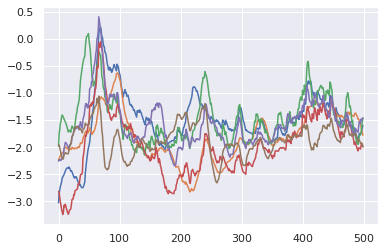

In [60]:
plt.plot(log_firing_rate.squeeze()[:,:])

In [39]:
to_plot_end = np.where(log_firing_rate.squeeze().mean(axis=1)>10)[0][0]
plt.plot(log_firing_rate.squeeze()[:to_plot_end,:])

IndexError: index 0 is out of bounds for axis 0 with size 0